<a href="https://colab.research.google.com/github/AjaySreekumar47/vlm-research/blob/main/EndoVis2017_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = "/content/drive/MyDrive/Endo2017"

for root, dirs, files in os.walk(base_path):
    print(f"\n📁 {root}")
    for file in files[:5]:  # Show only first 5 files per folder
        print("  └──", file)


📁 /content/drive/MyDrive/Endo2017
  └── instrument_type_mapping.json
  └── instrument_1_4_training.zip
  └── instrument_5_8_training.zip
  └── instrument_1_4_testing.zip
  └── instrument_5_8_testing.zip


In [3]:
import zipfile
import os

base_dir = "/content/drive/MyDrive/Endo2017"
extract_to = "/content/Endo2017_extracted"

# List of zips to extract (choose only training for now)
zip_files = [
    "instrument_1_4_training.zip",
    "instrument_5_8_training.zip"
]

os.makedirs(extract_to, exist_ok=True)

# Extract
for zip_file in zip_files:
    with zipfile.ZipFile(os.path.join(base_dir, zip_file), 'r') as zip_ref:
        zip_ref.extractall(extract_to)

print("✅ Extraction complete!")

✅ Extraction complete!


In [4]:
for root, dirs, files in os.walk(extract_to):
    print(f"\n📁 {root}")
    for file in files[:5]:  # Show first 5 files only
        print("  └──", file)


📁 /content/Endo2017_extracted
  └── mappings.json

📁 /content/Endo2017_extracted/instrument_dataset_3
  └── camera_calibration.txt

📁 /content/Endo2017_extracted/instrument_dataset_3/left_frames
  └── frame064.png
  └── frame140.png
  └── frame093.png
  └── frame179.png
  └── frame068.png

📁 /content/Endo2017_extracted/instrument_dataset_3/ground_truth

📁 /content/Endo2017_extracted/instrument_dataset_3/ground_truth/Left_Large_Needle_Driver_labels
  └── frame064.png
  └── frame140.png
  └── frame093.png
  └── frame179.png
  └── frame068.png

📁 /content/Endo2017_extracted/instrument_dataset_3/ground_truth/Right_Large_Needle_Driver_labels
  └── frame064.png
  └── frame140.png
  └── frame093.png
  └── frame179.png
  └── frame068.png

📁 /content/Endo2017_extracted/instrument_dataset_3/right_frames
  └── frame064.png
  └── frame140.png
  └── frame093.png
  └── frame179.png
  └── frame068.png

📁 /content/Endo2017_extracted/instrument_dataset_7
  └── camera_calibration.txt

📁 /content/Endo20

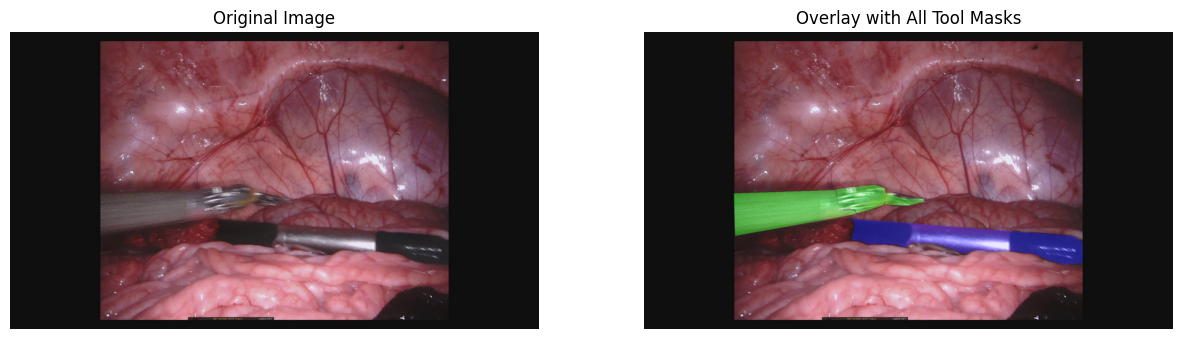

In [5]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Set dataset folder
dataset_folder = "/content/Endo2017_extracted/instrument_dataset_1"
frame_id = "frame064.png"

# Load image (e.g., left camera)
img_path = os.path.join(dataset_folder, "left_frames", frame_id)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create base overlay image
overlay = image.copy()

# Assign each tool a unique color
color_map = {
    0: (0, 0, 0),       # background
    1: (255, 0, 0),     # red
    2: (0, 255, 0),     # green
    3: (0, 0, 255),     # blue
    4: (255, 255, 0),   # cyan
    5: (255, 0, 255),   # magenta
    6: (0, 255, 255),   # yellow
}

# Loop through all label folders and overlay masks
label_dir = os.path.join(dataset_folder, "ground_truth")
label_folders = sorted(os.listdir(label_dir))

for idx, tool_folder in enumerate(label_folders):
    tool_mask_path = os.path.join(label_dir, tool_folder, frame_id)
    if not os.path.exists(tool_mask_path):
        continue

    mask = cv2.imread(tool_mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        continue

    # Create color mask and overlay
    color = color_map.get(idx+1, (128, 128, 128))  # avoid black for tools
    colored_mask = np.zeros_like(image)
    for i in range(3):
        colored_mask[:, :, i] = (mask > 0).astype(np.uint8) * color[i]
    overlay = cv2.addWeighted(overlay, 1.0, colored_mask, 0.4, 0)

# Plot
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Overlay with All Tool Masks")
plt.axis("off")

plt.show()

In [6]:
import json
import os

# Path to the mappings file
mapping_path = "/content/Endo2017_extracted/mappings.json"

# Load the file
with open(mapping_path, "r") as f:
    mappings = json.load(f)

# Display the content nicely
import pprint
pprint.pprint(mappings)

{'Background': 0, 'Claspers': 30, 'Probe': 40, 'Shaft': 10, 'Wrist': 20}


In [7]:
import json

mapping_path = "/content/drive/MyDrive/Endo2017/instrument_type_mapping.json"

with open(mapping_path, "r") as f:
    instrument_map = json.load(f)

import pprint
pprint.pprint(instrument_map)

{'Bipolar Forceps': 1,
 'Grasping Retractor': 5,
 'Large Needle Driver': 3,
 'Monopolar Curved Scissors': 6,
 'Other': 7,
 'Prograsp Forceps': 2,
 'Vessel Sealer': 4}


##  Section 2:  Indexing Image–Mask Pairs from EndoVis2017 Dataset

In [15]:
import os
import glob

def collect_image_mask_pairs(root_dir):
    image_mask_pairs = []

    # Traverse each instrument_dataset_X folder
    for dataset_folder in sorted(os.listdir(root_dir)):
        dataset_path = os.path.join(root_dir, dataset_folder)

        left_frames_dir = os.path.join(dataset_path, "left_frames")
        ground_truth_dir = os.path.join(dataset_path, "ground_truth")

        if not os.path.isdir(left_frames_dir) or not os.path.isdir(ground_truth_dir):
            continue  # Skip folders missing required subfolders

        # Get all frame images
        image_paths = sorted(glob.glob(os.path.join(left_frames_dir, "*.png")))

        for image_path in image_paths:
            frame_name = os.path.basename(image_path)

            # Find all masks for this frame across all instrument types
            mask_paths = sorted(glob.glob(os.path.join(ground_truth_dir, "*", frame_name)))

            if len(mask_paths) == 0:
                continue  # No masks found for this frame

            image_mask_pairs.append((image_path, mask_paths))

    return image_mask_pairs

# Usage
root_dir = "/content/Endo2017_extracted"
image_mask_pairs = collect_image_mask_pairs(root_dir)

print(f"✅ Found {len(image_mask_pairs)} image–mask pairs")
print("🖼️  Sample pair:")
for img, msk in image_mask_pairs[:1]:
    print(f"Image: {img}")
    print(f"Masks: {msk}")


✅ Found 1800 image–mask pairs
🖼️  Sample pair:
Image: /content/Endo2017_extracted/instrument_dataset_1/left_frames/frame000.png
Masks: ['/content/Endo2017_extracted/instrument_dataset_1/ground_truth/Left_Prograsp_Forceps_labels/frame000.png', '/content/Endo2017_extracted/instrument_dataset_1/ground_truth/Maryland_Bipolar_Forceps_labels/frame000.png', '/content/Endo2017_extracted/instrument_dataset_1/ground_truth/Other_labels/frame000.png', '/content/Endo2017_extracted/instrument_dataset_1/ground_truth/Right_Prograsp_Forceps_labels/frame000.png']


## Section 3: Custom Dataset Class

In [16]:
import glob

# Search for all JPG or PNG images in the extracted dataset
image_files = glob.glob("/content/Endo2017_extracted/**/*.jpg", recursive=True)
image_files += glob.glob("/content/Endo2017_extracted/**/*.png", recursive=True)

print(f"Found {len(image_files)} images")
print("Sample paths:")
for path in image_files[:10]:
    print(path)

Found 9225 images
Sample paths:
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame064.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame140.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame093.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame179.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame068.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame204.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame044.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame019.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame137.png
/content/Endo2017_extracted/instrument_dataset_3/left_frames/frame165.png


In [18]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

class EndoVisDataset(Dataset):
    def __init__(self, image_mask_pairs, transform=None, target_size=(256, 256)):
        self.pairs = image_mask_pairs
        self.transform = transform
        self.target_size = target_size

        # Default transforms if none provided
        self.default_img_transform = T.Compose([
            T.Resize(target_size),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_paths = self.pairs[idx]

        # Load image
        image = Image.open(image_path).convert("RGB")
        image = self.default_img_transform(image)

        # Prepare a blank mask
        mask = np.zeros(self.target_size, dtype=np.uint8)

        # Load and combine all binary masks (assuming foreground is white)
        for mpath in mask_paths:
            m = Image.open(mpath).convert("L").resize(self.target_size)
            m = np.array(m)
            mask = np.maximum(mask, (m > 0).astype(np.uint8))  # Combine masks

        # Convert to torch tensor
        mask = torch.from_numpy(mask).unsqueeze(0).float()  # Shape: [1, H, W]

        return image, mask

### 🔍 What This Dataset Class Does
1. Initialization (__init__):

- Takes a list of (image_path, [mask_paths]) pairs.

- Applies basic image transformations (resizing + converting to tensor).

- Sets a target size for all images and masks (default 256×256).

2. __len__ Method:

- Just returns the number of image–mask pairs.

3. __getitem__ Method:

- Loads one RGB image using its path.

- Initializes an empty binary mask (all zeros).

- Iterates over all mask paths for that image:

- Loads each grayscale mask.

- Resizes and binarizes it (pixel values > 0 become 1).

- Combines it with the existing mask using np.maximum() → this ensures any instrument pixel is marked as 1.

- Converts final combined mask to a PyTorch tensor with shape [1, H, W].

### ⚙️ Purpose
This class is designed to return:

1. An RGB image tensor: [3, 256, 256]

2. A binary segmentation mask tensor: [1, 256, 256]

3. Perfect for training models like U-Net.

## Section 4: Creating Train/Validation Splits and DataLoaders

In [19]:
from torch.utils.data import DataLoader, random_split

# Configuration
val_split_ratio = 0.2
batch_size = 8
num_workers = 2  # You can set to 0 if running into multiprocessing issues in Colab

# Step 1: Create the full dataset
full_dataset = EndoVisDataset(image_mask_pairs, target_size=(256, 256))

# Step 2: Train/Validation split
total_size = len(full_dataset)
val_size = int(total_size * val_split_ratio)
train_size = total_size - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Step 3: Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# 🧪 Sanity check
print(f"✅ DataLoaders ready:")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")
print(f"   Batch size: {batch_size}")

✅ DataLoaders ready:
   Training samples: 1440
   Validation samples: 360
   Batch size: 8


## Section 5: Visualize Image–Mask Batches

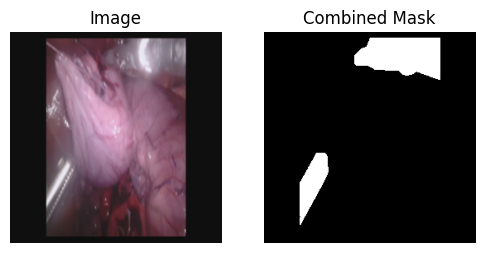

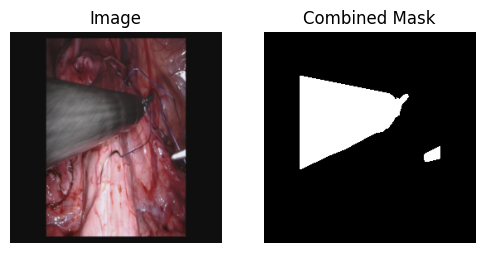

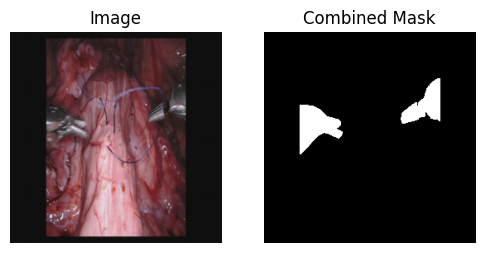

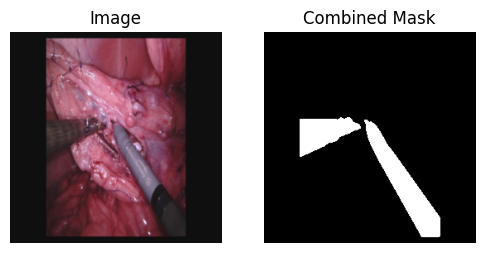

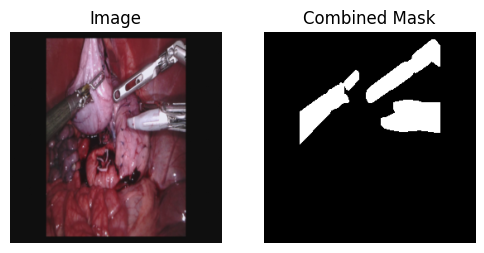

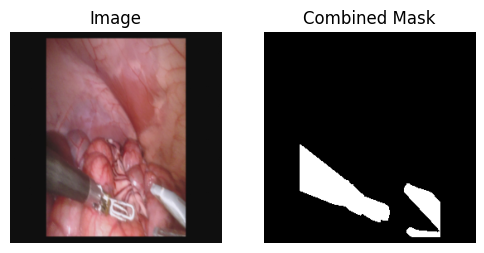

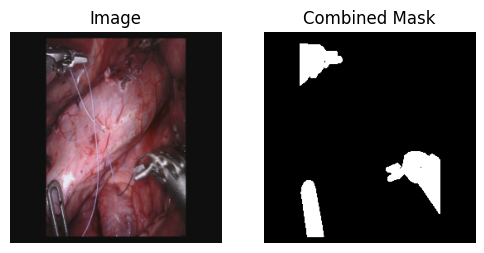

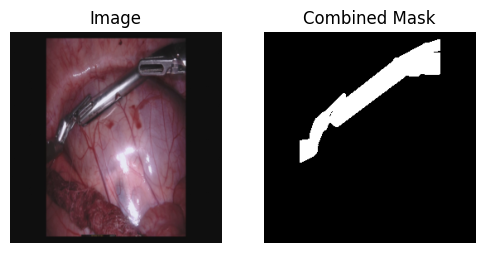

In [20]:
import matplotlib.pyplot as plt

# Function to show a batch of images and masks
def visualize_batch(dataloader, num_batches=1):
    model_input = next(iter(dataloader))
    images, masks = model_input

    batch_size = images.size(0)
    num_to_show = min(num_batches * batch_size, 8)  # Show up to 8 samples

    for i in range(num_to_show):
        image = images[i].permute(1, 2, 0).numpy()
        mask = masks[i][0].numpy()

        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='gray')
        plt.title("Combined Mask")
        plt.axis('off')
        plt.show()

# 🔍 Visualize a few training samples
visualize_batch(train_loader)

## Section 6: Model Setup and Training Loop

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import os
import time

# U-Net model from previous code (reused here)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)        # Output: 64
        self.down1 = Down(64, 128)                   # Output: 128
        self.down2 = Down(128, 256)                  # Output: 256
        self.down3 = Down(256, 512)                  # Output: 512
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)       # Output: 1024 // 2 = 512 if bilinear

        # Decoder
        self.up1 = Up(1024, 512 // factor, bilinear)     # x5 (512) + x4 (512) = 1024
        self.up2 = Up(512, 256 // factor, bilinear)      # x + x3 = 512
        self.up3 = Up(256, 128 // factor, bilinear)      # x + x2 = 256
        self.up4 = Up(128, 64, bilinear)                 # x + x1 = 128
        self.outc = OutConv(64, n_classes)               # Output segmentation map


    def forward(self, x):
      x1 = self.inc(x)
      x2 = self.down1(x1)
      x3 = self.down2(x2)
      x4 = self.down3(x3)
      x5 = self.down4(x4)
      x = self.up1(x5, x4)
      x = self.up2(x, x3)
      x = self.up3(x, x2)
      x = self.up4(x, x1)
      return self.outc(x)

## Section 7: Training Class & Metrics (Trainer)

In [32]:
def dice_coefficient(pred, target, smooth=1e-6):
    """Calculate Dice coefficient"""
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()

def iou_score(pred, target, smooth=1e-6):
    """Calculate IoU score"""
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

class Trainer:
    def __init__(self, model, train_loader, val_loader, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=1e-4)
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=5)

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_dice': [],
            'val_dice': [],
            'train_iou': [],
            'val_iou': []
        }

    def run_epoch(self, train=True):
        self.model.train() if train else self.model.eval()
        loader = self.train_loader if train else self.val_loader

        epoch_loss, epoch_dice, epoch_iou = 0, 0, 0
        mode = "Train" if train else "Val"

        with torch.set_grad_enabled(train):
            for images, masks in tqdm(loader, desc=mode):
                images, masks = images.to(self.device), masks.to(self.device).float()
                if len(masks.shape) == 3:
                    masks = masks.unsqueeze(1)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)

                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()

                dice = dice_coefficient(outputs, masks)
                iou = iou_score(outputs, masks)

                epoch_loss += loss.item()
                epoch_dice += dice.item()
                epoch_iou += iou.item()

        avg_loss = epoch_loss / len(loader)
        avg_dice = epoch_dice / len(loader)
        avg_iou = epoch_iou / len(loader)

        return avg_loss, avg_dice, avg_iou

    def train(self, epochs=10, save_path='/content/best_model.pth'):
        best_dice = 0.0

        for epoch in range(epochs):
            print(f"\n📅 Epoch {epoch+1}/{epochs}")

            train_loss, train_dice, train_iou = self.run_epoch(train=True)
            val_loss, val_dice, val_iou = self.run_epoch(train=False)

            self.scheduler.step(val_loss)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_dice'].append(train_dice)
            self.history['val_dice'].append(val_dice)
            self.history['train_iou'].append(train_iou)
            self.history['val_iou'].append(val_iou)

            print(f"📊 Train Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
            print(f"📊 Val   Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

            if val_dice > best_dice:
                best_dice = val_dice
                torch.save(self.model.state_dict(), save_path)
                print(f"💾 Saved best model with Dice: {best_dice:.4f}")

        return self.history

## Section 8: Training Entry Point

In [33]:
# Entry point for training
def train_model(train_loader, val_loader, num_epochs=10, save_path='/content/best_model.pth'):
    print("=" * 60)
    print("🚀 STARTING TRAINING PROCESS")
    print("=" * 60)

    # Initialize model and move to device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(n_channels=3, n_classes=1, bilinear=True)
    print(f"📦 Model created. Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Trainer setup
    trainer = Trainer(model, train_loader, val_loader, device=device)
    history = trainer.train(epochs=num_epochs, save_path=save_path)

    print("\n✅ Training complete!")
    return model, history

In [38]:
import matplotlib.pyplot as plt

def plot_training_metrics(history):
    """Plot loss, Dice score, and IoU over epochs"""
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(18, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_dice'], label='Train Dice')
    plt.plot(epochs, history['val_dice'], label='Val Dice')
    plt.title('Dice Score Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.legend()
    plt.grid(True)

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_iou'], label='Train IoU')
    plt.plot(epochs, history['val_iou'], label='Val IoU')
    plt.title('IoU Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
model, history = train_model(train_loader, val_loader, num_epochs=10)

🚀 STARTING TRAINING PROCESS
📦 Model created. Parameters: 13,395,329

📅 Epoch 1/10


Val: 100%|██████████| 45/45 [00:28<00:00,  1.59it/s]


📊 Train Loss: 0.2768 | Dice: 0.8706 | IoU: 0.7898
📊 Val   Loss: 0.2093 | Dice: 0.9267 | IoU: 0.8720
💾 Saved best model with Dice: 0.9267

📅 Epoch 2/10


Val: 100%|██████████| 45/45 [00:27<00:00,  1.63it/s]


📊 Train Loss: 0.1820 | Dice: 0.9250 | IoU: 0.8700
📊 Val   Loss: 0.1641 | Dice: 0.9134 | IoU: 0.8591

📅 Epoch 3/10


...

📊 Train Loss: 0.0465 | Dice: 0.9599 | IoU: 0.9270
📊 Val   Loss: 0.0471 | Dice: 0.9475 | IoU: 0.9140

📅 Epoch 9/10


Val: 100%|██████████| 45/45 [00:27<00:00,  1.65it/s]


📊 Train Loss: 0.0401 | Dice: 0.9602 | IoU: 0.9283
📊 Val   Loss: 0.0415 | Dice: 0.9616 | IoU: 0.9314
💾 Saved best model with Dice: 0.9616

📅 Epoch 10/10


Val: 100%|██████████| 45/45 [00:26<00:00,  1.68it/s]

📊 Train Loss: 0.0342 | Dice: 0.9657 | IoU: 0.9371
📊 Val   Loss: 0.0372 | Dice: 0.9594 | IoU: 0.9297

✅ Training complete!


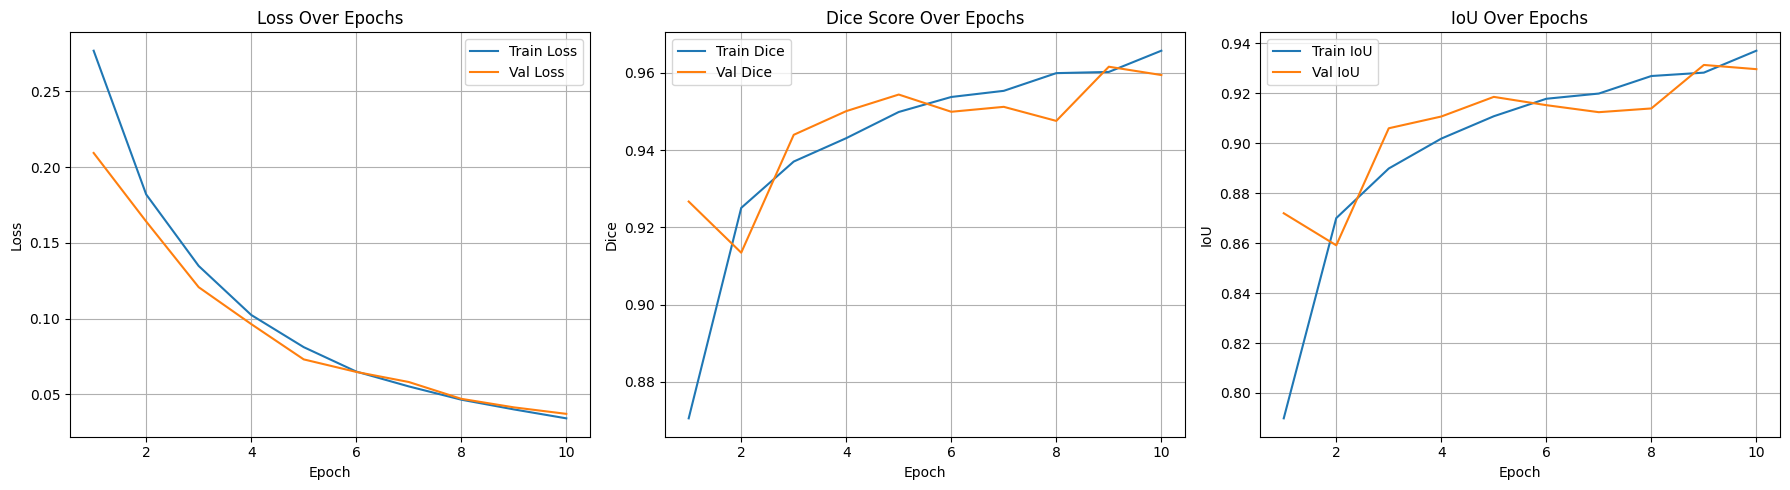

In [40]:
plot_training_metrics(history)

## Section 9: inference and visualization

In [41]:
import random
import matplotlib.pyplot as plt

def run_inference(model, dataloader, device='cuda', num_samples=5, threshold=0.5):
    model.eval()
    model.to(device)

    samples = random.sample(list(dataloader.dataset), num_samples)

    fig, axs = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    if num_samples == 1:
        axs = [axs]

    for i, (image, true_mask) in enumerate(samples):
        image_input = image.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(image_input)
            pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()

        # Apply threshold
        pred_mask_binary = (pred_mask > threshold).astype(np.uint8)
        true_mask_np = true_mask.squeeze().numpy()

        axs[i][0].imshow(image.permute(1, 2, 0).numpy())
        axs[i][0].set_title('Input Image')
        axs[i][0].axis('off')

        axs[i][1].imshow(true_mask_np, cmap='gray')
        axs[i][1].set_title('Ground Truth Mask')
        axs[i][1].axis('off')

        axs[i][2].imshow(pred_mask_binary, cmap='gray')
        axs[i][2].set_title('Predicted Mask')
        axs[i][2].axis('off')

    plt.tight_layout()
    plt.show()

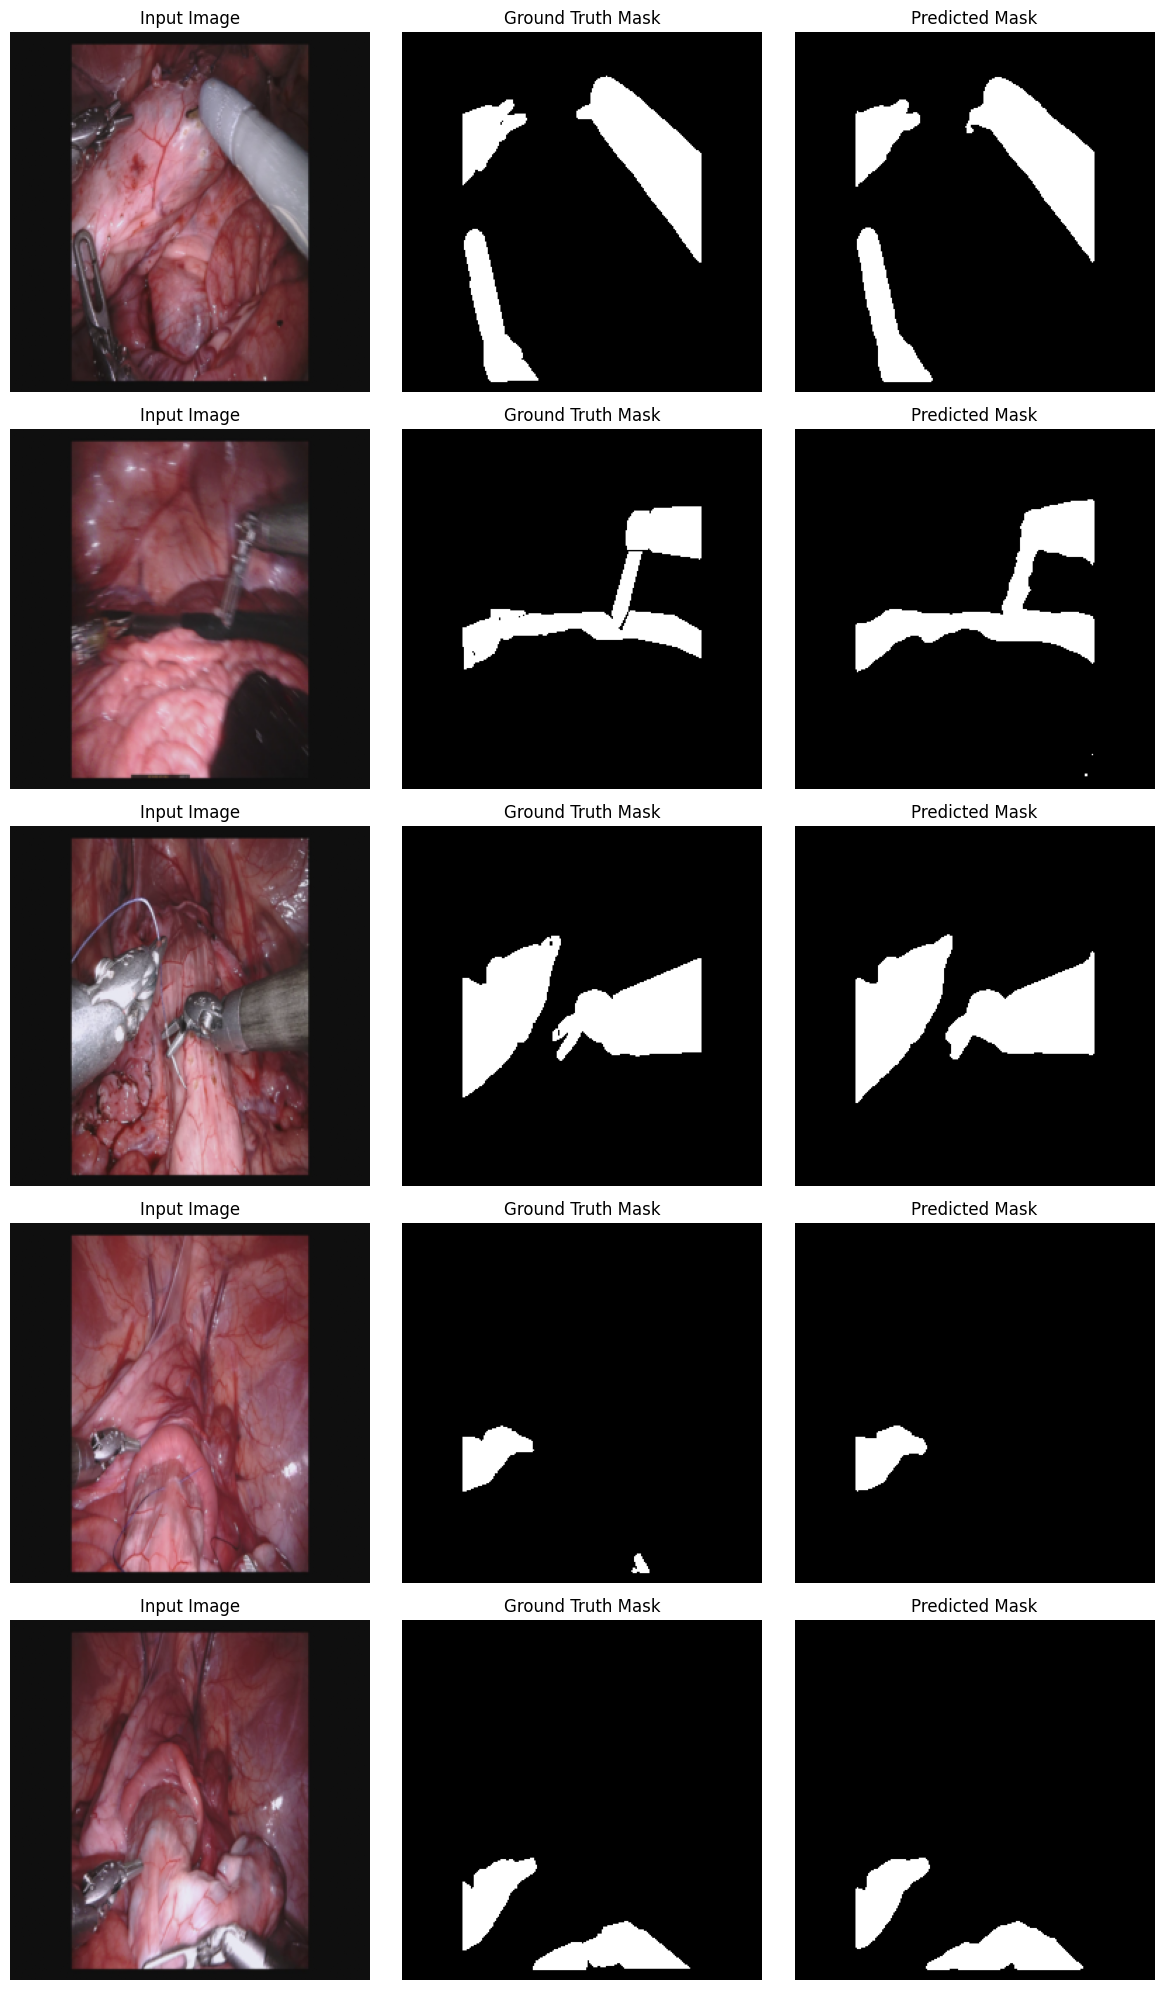

In [43]:
run_inference(model, val_loader, device='cuda', num_samples=5)